### Case Study: Loan Default Prediction using Support Vector Classifier (SVC)

---

### Business Context

In the banking industry, **loan default prediction** is a critical task. Banks need to identify borrowers who are likely to default on their loans to minimize financial losses and manage credit risk effectively.

This case study walks through the **end-to-end process** of building a **Support Vector Classifier (SVC)** model — from theory and mathematical foundations to implementation, evaluation, and hyperparameter tuning — using a synthetic banking dataset.

---

### Table of Contents

1. Theory: What is SVM / SVC?
2. Mathematical Foundations
3. Kernel Trick
4. Dataset Generation (Banking Domain)
5. Exploratory Data Analysis (EDA)
6. Data Preprocessing
7. Model Building — Basic SVC
8. Model Evaluation
9. Hyperparameter Tuning (GridSearchCV)
10. Tuned Model Evaluation & Comparison
11. Decision Boundary Visualization
12. Key Takeaways & Conclusion


---

### 1.Theory: What is SVM / SVC?

**Support Vector Machine (SVM)** is a supervised machine learning algorithm used for both **classification** (SVC) and **regression** (SVR) tasks.

### Core Intuition
SVM finds the **optimal hyperplane** that best separates data points of different classes with the **maximum margin**.

- **Hyperplane**: A decision boundary that separates classes. In 2D it's a line, in 3D it's a plane, and in higher dimensions it's a hyperplane.
- **Support Vectors**: The data points closest to the hyperplane. These are the most critical points — they define the margin.
- **Margin**: The distance between the hyperplane and the nearest support vectors from each class. SVM maximizes this margin.

> **Key Idea**: Among all possible hyperplanes that separate the classes, SVM picks the one with the **largest margin** → better generalization.

### When to Use SVC?

| ✅ Strengths | ❌ Limitations |
|---|---|
| Effective in high-dimensional spaces | Not ideal for very large datasets (slow training) |
| Works well with clear margin of separation | Sensitive to noisy data & overlapping classes |
| Memory efficient (uses support vectors only) | Doesn't directly provide probability estimates |
| Versatile — different kernels for different data | Requires feature scaling |


---

## 2. Mathematical Foundations

## 2.1 Hyperplane Equation

The decision boundary (hyperplane) is defined as:

$$\mathbf{w} \cdot \mathbf{x} + b = 0$$

Where:
- $\mathbf{w}$ = weight vector (normal to the hyperplane)
- $\mathbf{x}$ = input feature vector
- $b$ = bias term

For classification:
- If $\mathbf{w} \cdot \mathbf{x} + b > 0$ → Class +1
- If $\mathbf{w} \cdot \mathbf{x} + b < 0$ → Class -1

## 2.2 Margin Maximization

The margin is the distance between two parallel hyperplanes:

$$\mathbf{w} \cdot \mathbf{x} + b = +1 \quad \text{and} \quad \mathbf{w} \cdot \mathbf{x} + b = -1$$

The width of the margin is:

$$\text{Margin} = \frac{2}{\|\mathbf{w}\|}$$

**Objective**: Maximize the margin → Minimize $\|\mathbf{w}\|$

## 2.3 Hard Margin SVM (Linearly Separable)

$$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2$$

Subject to:

$$y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1 \quad \forall \; i = 1, 2, ..., n$$

## 2.4 Soft Margin SVM (Non-Linearly Separable)

Real data is rarely perfectly separable. We introduce **slack variables** $\xi_i$ to allow some misclassification:

$$\min_{\mathbf{w}, b, \xi} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \xi_i$$

Subject to:

$$y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

Where:
- $C$ = **Regularization parameter** — controls the trade-off between maximizing the margin and minimizing classification error
  - **Large C**: Less tolerance for misclassification (may overfit)
  - **Small C**: Wider margin, more tolerance (may underfit)


---

### 3. The Kernel Trick

When data is not linearly separable, SVM uses the **kernel trick** to map data into a higher-dimensional space where a linear separator exists.

$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j)$$

### Common Kernels

| Kernel | Formula | Best For |
|---|---|---|
| **Linear** | $K(\mathbf{x}, \mathbf{y}) = \mathbf{x} \cdot \mathbf{y}$ | Linearly separable data |
| **RBF (Gaussian)** | $K(\mathbf{x}, \mathbf{y}) = \exp\left(-\gamma \|\mathbf{x} - \mathbf{y}\|^2\right)$ | Most common, non-linear data |
| **Polynomial** | $K(\mathbf{x}, \mathbf{y}) = (\mathbf{x} \cdot \mathbf{y} + c)^d$ | Polynomial decision boundaries |
| **Sigmoid** | $K(\mathbf{x}, \mathbf{y}) = \tanh(\gamma \cdot \mathbf{x} \cdot \mathbf{y} + c)$ | Neural network-like behavior |

### Key Hyperparameters
- **C** (Regularization): Trade-off between smooth boundary and classifying training points correctly
- **gamma** ($\gamma$): Defines the influence of a single training example
  - High gamma → points close to boundary have high weight (risk of overfitting)
  - Low gamma → far-away points also considered (smoother boundary)


In [1]:
# ============================================================
# Import Required Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_curve, auc, precision_recall_curve, 
                             accuracy_score, f1_score)
from sklearn.decomposition import PCA

# Plot settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print("All libraries imported successfully!")


All libraries imported successfully!


---

### 4. Dataset Generation — Banking Loan Default Dataset

We generate a **synthetic but realistic** banking dataset with 2,000 customers and features commonly used in credit risk modeling.


In [2]:
# ============================================================
# Generate Synthetic Banking Dataset
# ============================================================
np.random.seed(42)
n = 2150

# Generate features
age = np.random.randint(21, 65, n)
annual_income = np.random.normal(55000, 20000, n).clip(15000, 200000)
credit_score = np.random.normal(650, 80, n).clip(300, 850).astype(int)
loan_amount = np.random.normal(150000, 80000, n).clip(5000, 500000)
employment_years = np.random.exponential(5, n).clip(0, 35).round(1)
debt_to_income = np.random.normal(0.35, 0.15, n).clip(0.05, 0.95)
num_credit_lines = np.random.poisson(5, n).clip(1, 20)
monthly_balance = np.random.normal(3000, 2000, n).clip(-2000, 20000)
previous_defaults = np.random.choice([0, 1, 2, 3], n, p=[0.65, 0.20, 0.10, 0.05])

# Create target variable with realistic correlations
default_prob = (
    -0.01 * (credit_score - 500)
    + 0.00001 * (loan_amount - 100000)
    + 2.0 * (debt_to_income - 0.3)
    + 1.5 * previous_defaults
    - 0.02 * (annual_income - 40000) / 10000
    - 0.1 * employment_years
    + 0.005 * (age - 40)
    - 0.0002 * monthly_balance
)

# Convert to probability using sigmoid
default_prob = 1 / (1 + np.exp(-default_prob))
loan_default = (np.random.rand(n) < default_prob).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'Age': age,
    'Annual_Income': annual_income.round(2),
    'Credit_Score': credit_score,
    'Loan_Amount': loan_amount.round(2),
    'Employment_Years': employment_years,
    'Debt_to_Income_Ratio': debt_to_income.round(4),
    'Num_Credit_Lines': num_credit_lines,
    'Monthly_Balance': monthly_balance.round(2),
    'Previous_Defaults': previous_defaults,
    'Loan_Default': loan_default
})

print(f"Dataset Shape: {df.shape}")
print(f"\nTarget Distribution:\n{df['Loan_Default'].value_counts()}")
print(f"\nDefault Rate: {df['Loan_Default'].mean()*100:.1f}%")
df.head(10)


Dataset Shape: (2150, 10)

Target Distribution:
Loan_Default
0    1475
1     675
Name: count, dtype: int64

Default Rate: 31.4%


,Age,Annual_Income,Credit_Score,Loan_Amount,Employment_Years,Debt_to_Income_Ratio,Num_Credit_Lines,Monthly_Balance,Previous_Defaults,Loan_Default
0,59,84189.87,633,119342.81,1.2,0.4071,7,3404.93,0,0
1,49,21293.78,714,193339.01,6.3,0.5819,9,3369.55,0,0
2,35,61287.67,588,132428.40,8.0,0.3631,3,1081.65,0,1
3,63,54958.32,614,98425.92,2.1,0.1944,5,3135.56,2,1
4,28,63290.84,632,176497.54,0.9,0.5265,2,3517.42,3,0
5,41,39553.92,558,279455.40,0.0,0.2635,5,2398.69,0,0
6,59,26287.62,589,186913.99,3.0,0.3943,4,7478.37,0,0
7,39,16737.87,663,254075.32,2.2,0.3779,7,2732.05,0,0
8,43,74527.68,746,103790.86,4.0,0.3568,3,-526.70,1,1
9,31,77080.98,675,149331.03,1.0,0.3245,3,979.41,0,0


---

### 5. Exploratory Data Analysis (EDA)


In [3]:
# ============================================================
# 5.1 Basic Dataset Information
# ============================================================
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
df.describe().round(2)


DATASET INFO
Shape: (2150, 10)

Data Types:
Age                       int32
Annual_Income           float64
Credit_Score              int32
Loan_Amount             float64
Employment_Years        float64
Debt_to_Income_Ratio    float64
Num_Credit_Lines          int32
Monthly_Balance         float64
Previous_Defaults         int32
Loan_Default              int32
dtype: object

Missing Values:
Age                     0
Annual_Income           0
Credit_Score            0
Loan_Amount             0
Employment_Years        0
Debt_to_Income_Ratio    0
Num_Credit_Lines        0
Monthly_Balance         0
Previous_Defaults       0
Loan_Default            0
dtype: int64

STATISTICAL SUMMARY


,Age,Annual_Income,Credit_Score,Loan_Amount,Employment_Years,Debt_to_Income_Ratio,Num_Credit_Lines,Monthly_Balance,Previous_Defaults,Loan_Default
count,2150.00,2150.00,2150.00,2150.00,2150.00,2150.00,2150.00,2150.00,2150.00,2150.00
mean,42.63,54803.45,647.09,149051.17,5.05,0.35,5.10,2986.99,0.57,0.31
std,12.59,19366.19,78.66,80362.43,4.97,0.14,2.26,1988.85,0.88,0.46
min,21.00,15000.00,363.00,5000.00,0.00,0.05,1.00,-2000.00,0.00,0.00
25%,32.00,41047.76,595.00,91679.80,1.50,0.25,3.00,1599.95,0.00,0.00
50%,43.00,54882.51,646.00,147647.82,3.50,0.35,5.00,2947.29,0.00,0.00
75%,53.00,68461.70,699.00,203152.60,7.10,0.44,7.00,4317.96,1.00,1.00
max,64.00,116238.94,850.00,412111.95,35.00,0.82,15.00,10374.93,3.00,1.00


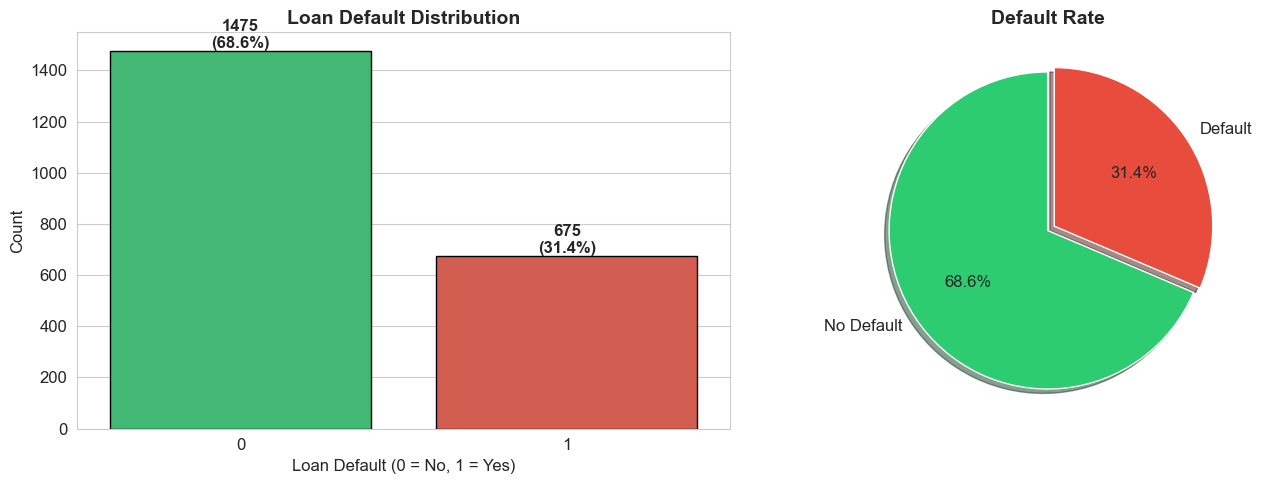

In [4]:
# ============================================================
# 5.2 Target Variable Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
colors = ['#2ecc71', '#e74c3c']
ax1 = sns.countplot(x='Loan_Default', data=df, palette=colors, ax=axes[0], edgecolor='black')
axes[0].set_title('Loan Default Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Default (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)', 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontweight='bold')

# Pie chart
df['Loan_Default'].value_counts().plot.pie(autopct='%1.1f%%', colors=colors, 
                                            labels=['No Default', 'Default'],
                                            ax=axes[1], startangle=90,
                                            explode=(0, 0.05), shadow=True)
axes[1].set_title('Default Rate', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


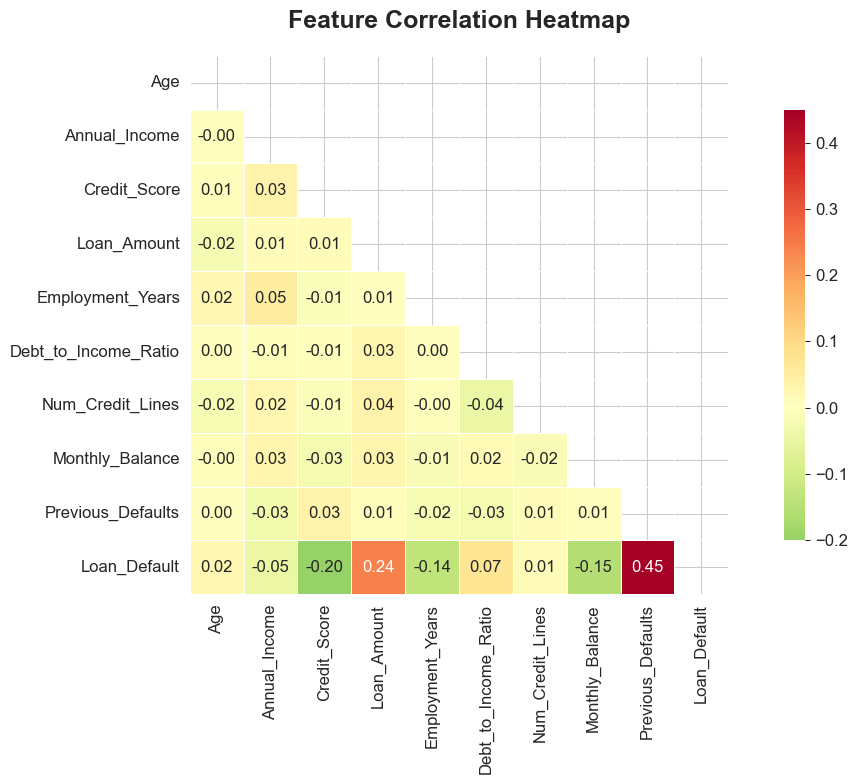

In [5]:
# ============================================================
# 5.3 Correlation Heatmap
# ============================================================
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            center=0, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


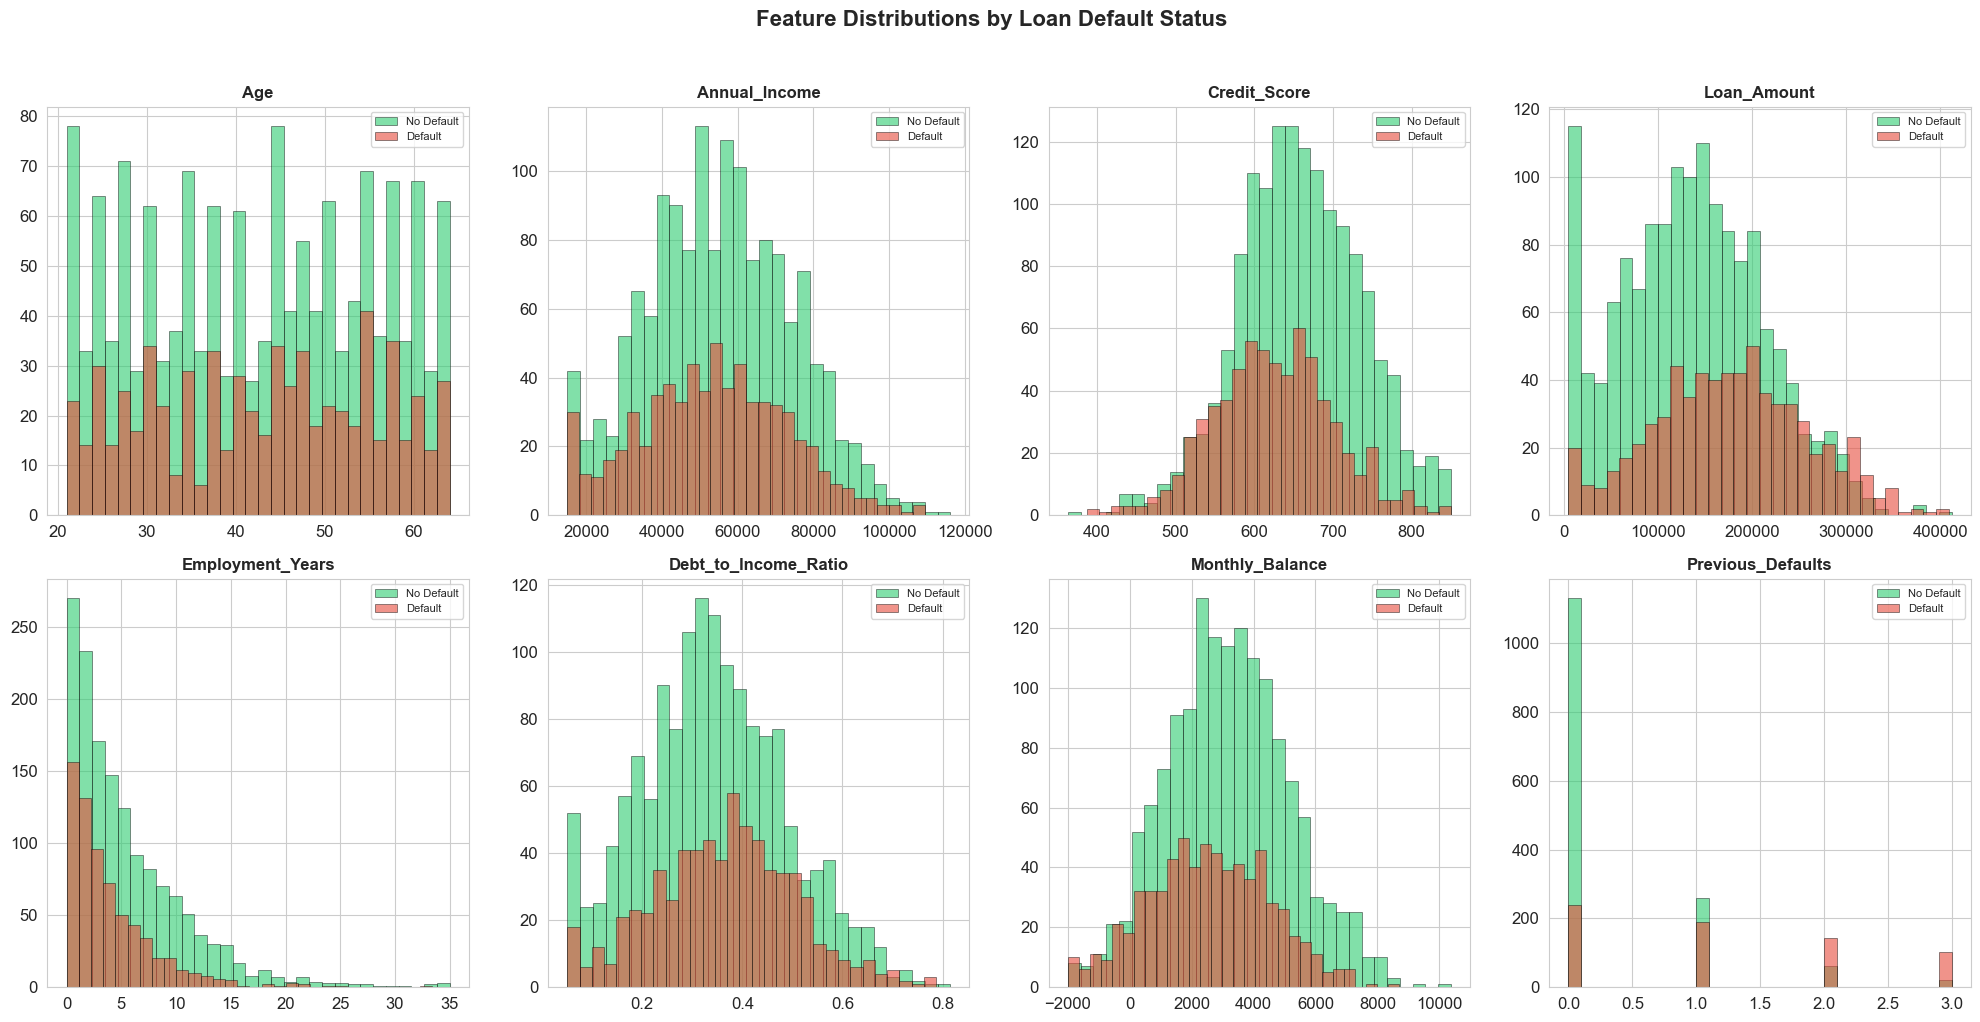

In [6]:
# ============================================================
# 5.4 Feature Distributions
# ============================================================
features = ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 
            'Employment_Years', 'Debt_to_Income_Ratio', 'Monthly_Balance', 'Previous_Defaults']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, col in enumerate(features):
    for target, color, label in [(0, '#2ecc71', 'No Default'), (1, '#e74c3c', 'Default')]:
        axes[i].hist(df[df['Loan_Default'] == target][col], bins=30, alpha=0.6, 
                     color=color, label=label, edgecolor='black', linewidth=0.5)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Loan Default Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


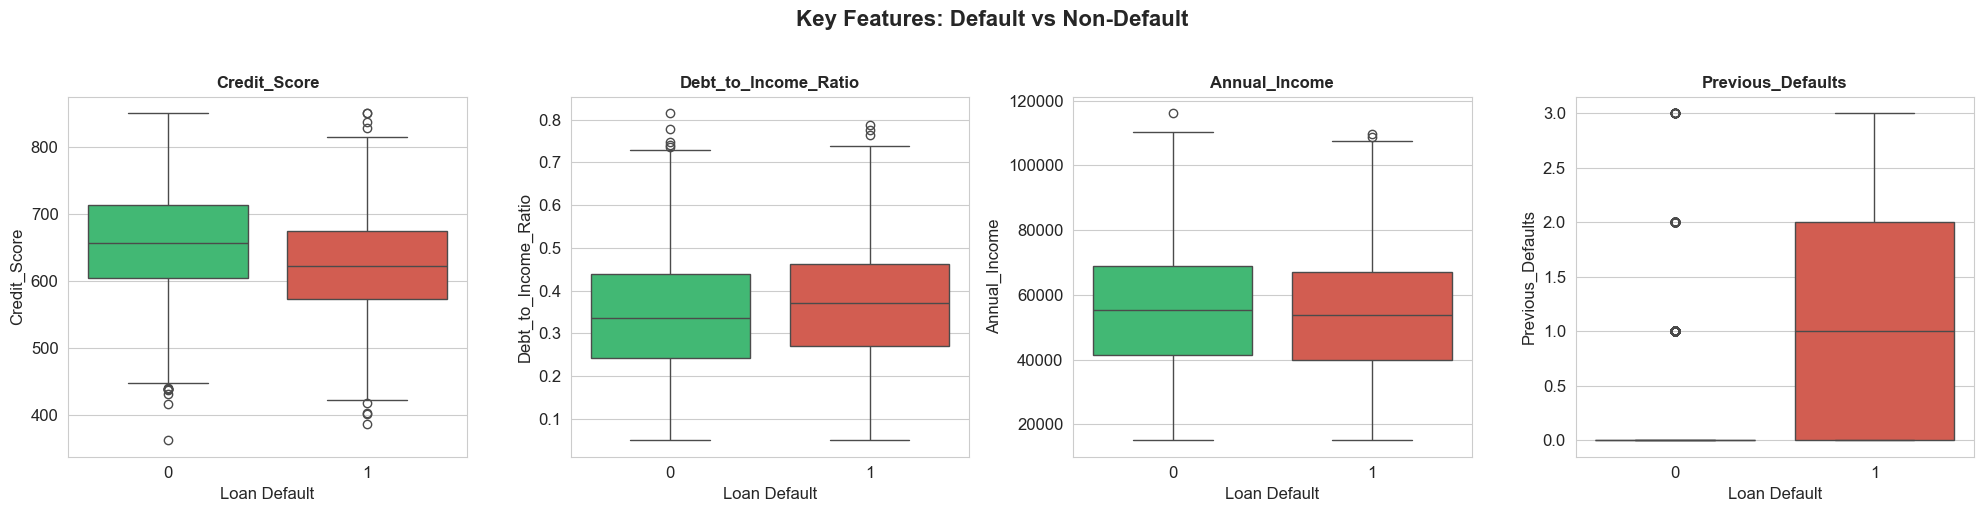

In [7]:
# ============================================================
# 5.5 Boxplots — Key Features by Target Class
# ============================================================
key_features = ['Credit_Score', 'Debt_to_Income_Ratio', 'Annual_Income', 'Previous_Defaults']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(key_features):
    sns.boxplot(x='Loan_Default', y=col, data=df, palette=colors, ax=axes[i])
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Loan Default')

plt.suptitle('Key Features: Default vs Non-Default', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---

### 6. Data Preprocessing

### Steps:
1. **Separate features (X) and target (y)**
2. **Train-Test Split** (80/20)
3. **Feature Scaling** using StandardScaler — **essential for SVM** as it is distance-based


In [8]:
# ============================================================
# 6.1 Feature-Target Split
# ============================================================
X = df.drop('Loan_Default', axis=1)
y = df['Loan_Default']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")

# ============================================================
# 6.2 Train-Test Split (80/20)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")
print(f"\nTrain default rate: {y_train.mean()*100:.1f}%")
print(f"Test default rate:  {y_test.mean()*100:.1f}%")

# ============================================================
# 6.3 Feature Scaling (StandardScaler)
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Feature scaling complete!")
print(f"Scaled train mean (sample): {X_train_scaled.mean(axis=0)[:3].round(4)}")
print(f"Scaled train std  (sample): {X_train_scaled.std(axis=0)[:3].round(4)}")


Features shape: (2150, 9)
Target shape:   (2150,)

Train set: 1720 samples
Test set:  430 samples

Train default rate: 31.4%
Test default rate:  31.4%

 Feature scaling complete!
Scaled train mean (sample): [ 0.  0. -0.]
Scaled train std  (sample): [1. 1. 1.]


---

### 7. Model Building — Basic SVC

We train two baseline SVC models:
1. **Linear Kernel** — assumes linear separability
2. **RBF Kernel** — handles non-linear patterns (default in sklearn)


In [9]:
# ============================================================
# 7.1 SVC with Linear Kernel
# ============================================================
svc_linear = SVC(kernel='linear', random_state=42, probability=True)
svc_linear.fit(X_train_scaled, y_train)
y_pred_linear = svc_linear.predict(X_test_scaled)
acc_linear = accuracy_score(y_test, y_pred_linear)

print("=" * 50)
print("SVC — LINEAR KERNEL")
print("=" * 50)
print(f"Accuracy: {acc_linear*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_linear)*100:.2f}%")

SVC — LINEAR KERNEL
Accuracy: 80.47%
F1 Score: 65.29%


In [10]:


# ============================================================
# 7.2 SVC with RBF Kernel
# ============================================================
svc_rbf = SVC(kernel='rbf', random_state=42, probability=True)
svc_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svc_rbf.predict(X_test_scaled)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print("\n" + "=" * 50)
print("SVC — RBF KERNEL")
print("=" * 50)
print(f"Accuracy: {acc_rbf*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_rbf)*100:.2f}%")



SVC — RBF KERNEL
Accuracy: 78.84%
F1 Score: 60.94%


In [11]:

# ============================================================
# 7.3 Comparison Table
# ============================================================
comparison = pd.DataFrame({
    'Kernel': ['Linear', 'RBF'],
    'Accuracy (%)': [acc_linear*100, acc_rbf*100],
    'F1 Score (%)': [f1_score(y_test, y_pred_linear)*100, f1_score(y_test, y_pred_rbf)*100]
}).round(2)
print("\n Baseline Comparison:")
print(comparison.to_string(index=False))



 Baseline Comparison:
Kernel  Accuracy (%)  F1 Score (%)
Linear         80.47         65.29
   RBF         78.84         60.94


---

### 8. Model Evaluation

We evaluate the **RBF kernel** model (typically the stronger baseline) using:
- Confusion Matrix
- Classification Report
- ROC Curve & AUC
- Precision-Recall Curve


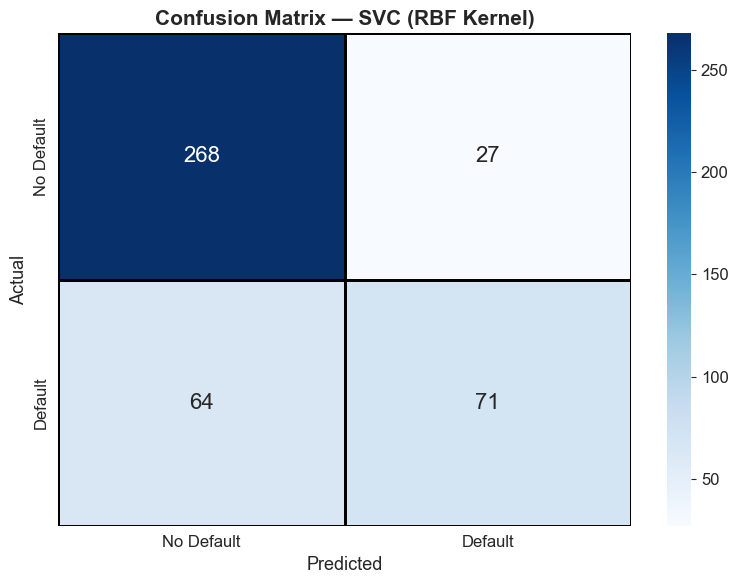

True Postives:  71
False Positives: 27
False Negatives: 64
True Negatives:  268


In [13]:
# ============================================================
# 8.1 Confusion Matrix
# ============================================================
cm = confusion_matrix(y_test, y_pred_rbf)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            annot_kws={'size': 16}, linewidths=1, linecolor='black')
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix — SVC (RBF Kernel)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Print
tn, fp, fn, tp = cm.ravel()
print(f"True Postives:  {tp}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Negatives:  {tn}")


In [14]:
# ============================================================
# 8.2 Classification Report
# ============================================================
print("=" * 60)
print("CLASSIFICATION REPORT — SVC (RBF Kernel)")
print("=" * 60)
print(classification_report(y_test, y_pred_rbf, target_names=['No Default', 'Default']))


CLASSIFICATION REPORT — SVC (RBF Kernel)
              precision    recall  f1-score   support

  No Default       0.81      0.91      0.85       295
     Default       0.72      0.53      0.61       135

    accuracy                           0.79       430
   macro avg       0.77      0.72      0.73       430
weighted avg       0.78      0.79      0.78       430



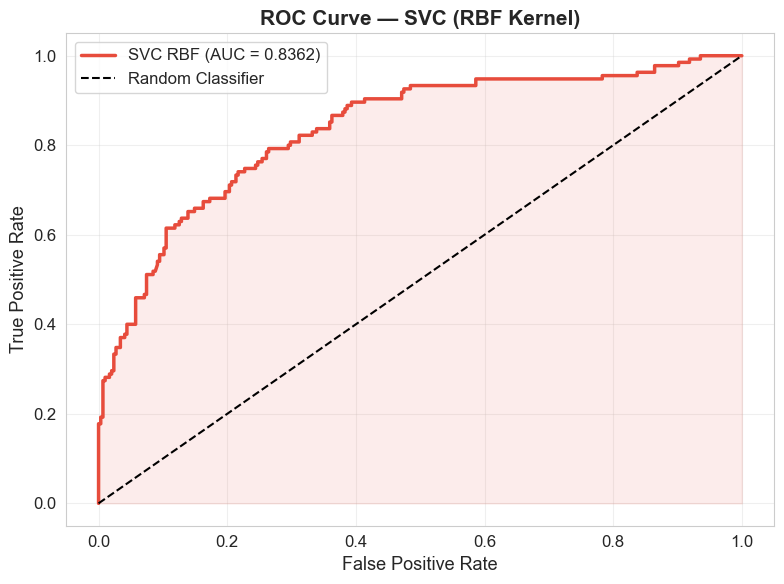

AUC Score: 0.8362


In [15]:
# ============================================================
# 8.3 ROC Curve & AUC Score
# ============================================================
y_prob_rbf = svc_rbf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rbf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'SVC RBF (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve — SVC (RBF Kernel)', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"AUC Score: {roc_auc:.4f}")


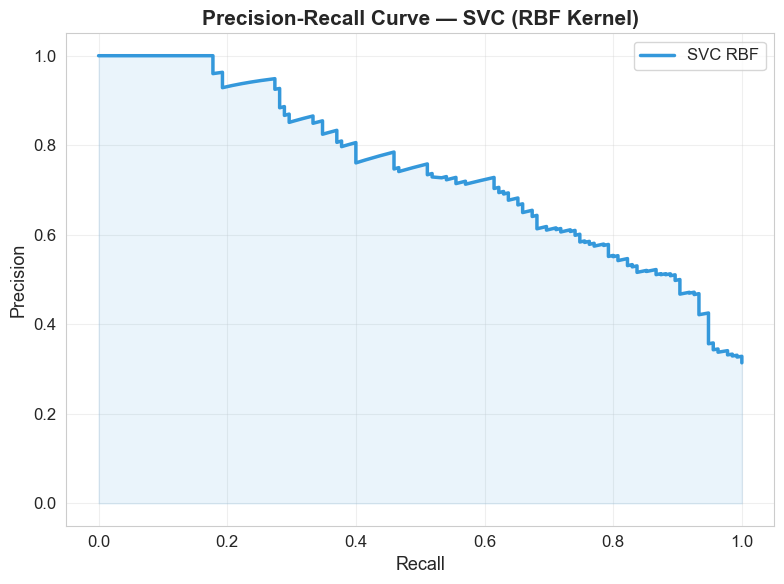

In [16]:
# ============================================================
# 8.4 Precision-Recall Curve
# ============================================================
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob_rbf)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='#3498db', lw=2.5, label='SVC RBF')
plt.fill_between(recall_vals, precision_vals, alpha=0.1, color='#3498db')
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Precision-Recall Curve — SVC (RBF Kernel)', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---

### 9.Hyperparameter Tuning (GridSearchCV)

We use **GridSearchCV** with 5-fold cross-validation to find the optimal combination of:

| Parameter | Values | Description |
|---|---|---|
| **C** | 0.1, 1, 10, 100 | Regularization strength |
| **gamma** | 'scale', 'auto', 0.1, 0.01 | Kernel coefficient for RBF |
| **kernel** | 'linear', 'rbf', 'poly' | Type of kernel function |

Total combinations: $4 \times 4 \times 3 = 48$ combinations × 5 folds = **240 fits**


In [17]:
# ============================================================
# 9.1 Define Parameter Grid
# ============================================================
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['linear', 'rbf', 'poly']
}

# ============================================================
# 9.2 Run GridSearchCV
# ============================================================
print("Running GridSearchCV... (this may take a minute)")

grid_search = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

grid_search.fit(X_train_scaled, y_train)

print("\nGridSearchCV Complete!")
print(f"\n Best Parameters: {grid_search.best_params_}")
print(f" Best CV F1 Score: {grid_search.best_score_*100:.2f}%")


Running GridSearchCV... (this may take a minute)

GridSearchCV Complete!

 Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
 Best CV F1 Score: 65.31%


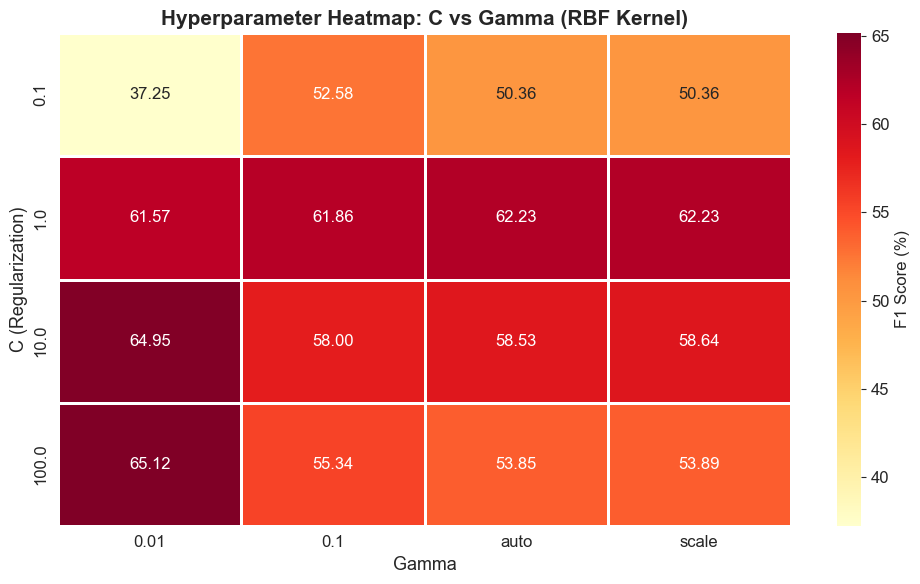

In [18]:
# ============================================================
# 9.3 C vs Gamma Performance Heatmap (RBF Kernel only)
# ============================================================
results = pd.DataFrame(grid_search.cv_results_)

# Filter RBF results for heatmap
rbf_results = results[results['param_kernel'] == 'rbf']
pivot = rbf_results.pivot_table(
    values='mean_test_score', 
    index='param_C', 
    columns='param_gamma'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot * 100, annot=True, fmt='.2f', cmap='YlOrRd', 
            linewidths=1, linecolor='white',
            cbar_kws={'label': 'F1 Score (%)'})
plt.title('Hyperparameter Heatmap: C vs Gamma (RBF Kernel)', fontsize=15, fontweight='bold')
plt.xlabel('Gamma', fontsize=13)
plt.ylabel('C (Regularization)', fontsize=13)
plt.tight_layout()
plt.show()


In [19]:
# ============================================================
# 9.4 Cross-Validation Scores with Best Model
# ============================================================
best_model = grid_search.best_estimator_
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='f1')

print("5-Fold Cross-Validation F1 Scores:")
print("-" * 40)
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score*100:.2f}%")
print("-" * 40)
print(f"  Mean:  {cv_scores.mean()*100:.2f}%")
print(f"  Std:   {cv_scores.std()*100:.2f}%")


5-Fold Cross-Validation F1 Scores:
----------------------------------------
  Fold 1: 64.62%
  Fold 2: 66.67%
  Fold 3: 69.47%
  Fold 4: 60.54%
  Fold 5: 65.24%
----------------------------------------
  Mean:  65.31%
  Std:   2.91%


---

### 10.Tuned Model Evaluation & Comparison


TUNED MODEL — CLASSIFICATION REPORT
Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
              precision    recall  f1-score   support

  No Default       0.83      0.91      0.86       295
     Default       0.74      0.59      0.65       135

    accuracy                           0.80       430
   macro avg       0.78      0.75      0.76       430
weighted avg       0.80      0.80      0.80       430



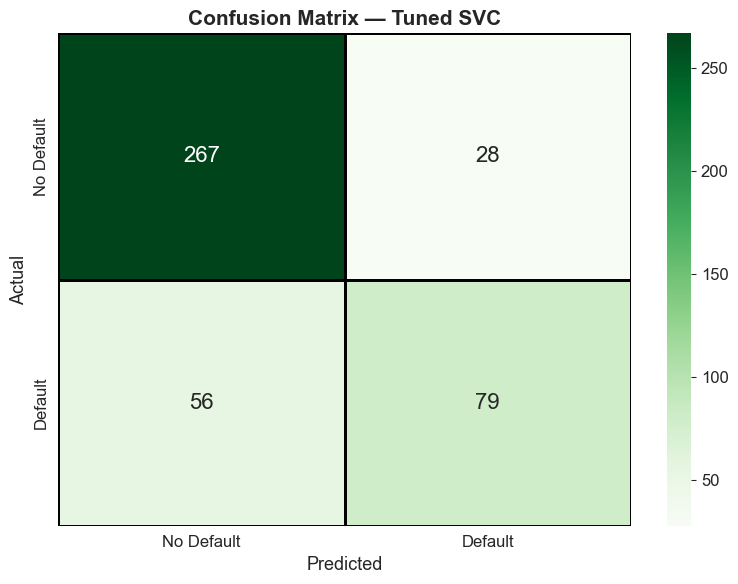

In [20]:
# ============================================================
# 10.1 Evaluate Tuned Model on Test Set
# ============================================================
y_pred_tuned = best_model.predict(X_test_scaled)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("=" * 60)
print("TUNED MODEL — CLASSIFICATION REPORT")
print(f"Best Params: {grid_search.best_params_}")
print("=" * 60)
print(classification_report(y_test, y_pred_tuned, target_names=['No Default', 'Default']))

# ============================================================
# 10.2 Tuned Model — Confusion Matrix
# ============================================================
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            annot_kws={'size': 16}, linewidths=1, linecolor='black')
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix — Tuned SVC', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


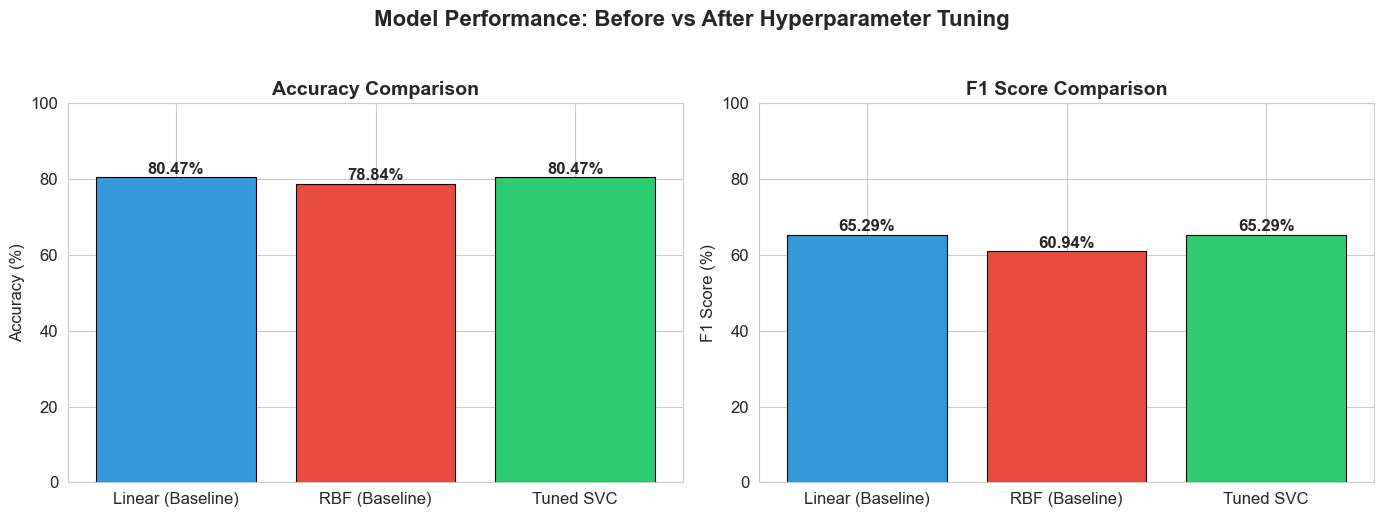

In [21]:
# ============================================================
# 10.3 Before vs After Tuning — Comparison Bar Chart
# ============================================================
models = ['Linear (Baseline)', 'RBF (Baseline)', 'Tuned SVC']
accuracies = [acc_linear * 100, acc_rbf * 100, acc_tuned * 100]
f1_scores_list = [
    f1_score(y_test, y_pred_linear) * 100, 
    f1_score(y_test, y_pred_rbf) * 100, 
    f1_tuned * 100
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
bars1 = axes[0].bar(models, accuracies, color=['#3498db', '#e74c3c', '#2ecc71'], 
                     edgecolor='black', linewidth=0.8)
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                 f'{val:.2f}%', ha='center', fontweight='bold')

# F1 Score comparison
bars2 = axes[1].bar(models, f1_scores_list, color=['#3498db', '#e74c3c', '#2ecc71'], 
                     edgecolor='black', linewidth=0.8)
axes[1].set_title('F1 Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1 Score (%)')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars2, f1_scores_list):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                 f'{val:.2f}%', ha='center', fontweight='bold')

plt.suptitle('Model Performance: Before vs After Hyperparameter Tuning', 
             fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


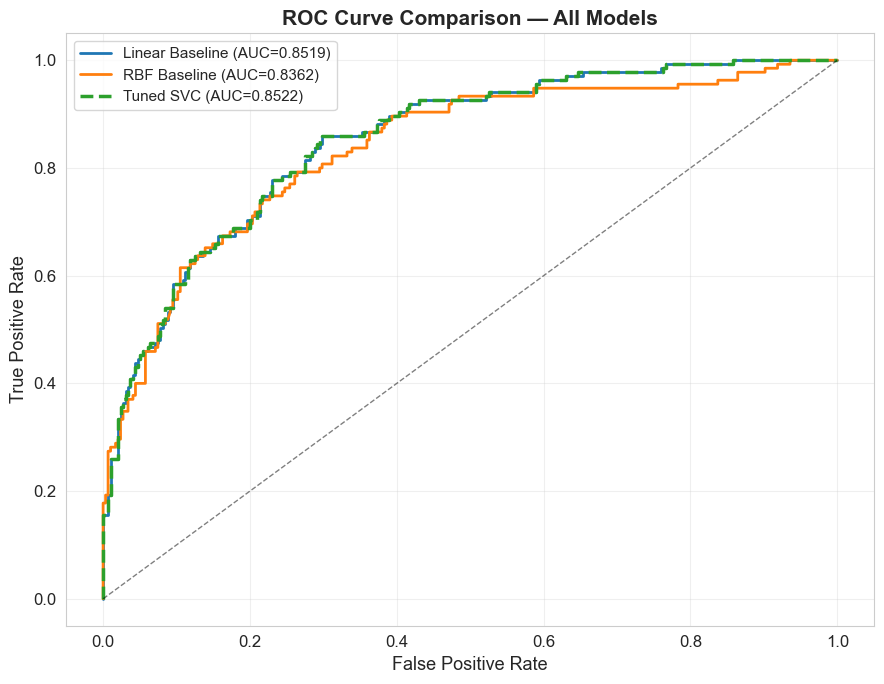

In [22]:
# ============================================================
# 10.4 ROC Curve Comparison — All Models
# ============================================================
plt.figure(figsize=(9, 7))

# Linear
y_prob_lin = svc_linear.predict_proba(X_test_scaled)[:, 1]
fpr_lin, tpr_lin, _ = roc_curve(y_test, y_prob_lin)
auc_lin = auc(fpr_lin, tpr_lin)
plt.plot(fpr_lin, tpr_lin, lw=2, label=f'Linear Baseline (AUC={auc_lin:.4f})')

# RBF Baseline
plt.plot(fpr, tpr, lw=2, label=f'RBF Baseline (AUC={roc_auc:.4f})')

# Tuned
y_prob_tuned = best_model.predict_proba(X_test_scaled)[:, 1]
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_tuned)
auc_t = auc(fpr_t, tpr_t)
plt.plot(fpr_t, tpr_t, lw=2.5, label=f'Tuned SVC (AUC={auc_t:.4f})', linestyle='--')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve Comparison — All Models', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---

### 11. Decision Boundary Visualization (PCA → 2D)

Since our dataset has 9 features, we use **Principal Component Analysis (PCA)** to reduce it to 2 dimensions for visualization of the SVC decision boundary.


In [ ]:
# ============================================================
# 11.1 PCA Reduction to 2D
# ============================================================
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_.round(4)}")
print(f"Total Variance Explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# ============================================================
# 11.2 Train SVC on 2D PCA Data
# ============================================================
svc_pca = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svc_pca.fit(X_train_pca, y_train)

# ============================================================
# 11.3 Plot Decision Boundary
# ============================================================
def plot_decision_boundary(X, y, model, title):
    h = 0.1  # step size
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
    plt.contour(xx, yy, Z, colors='black', linewidths=0.5)
    
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlGn', 
                         edgecolors='black', linewidth=0.5, s=20, alpha=0.7)
    
    # Highlight support vectors
    sv = model.support_vectors_
    plt.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none', 
               edgecolors='blue', linewidths=1.5, label=f'Support Vectors (n={len(sv)})')
    
    plt.xlabel('PC1', fontsize=13)
    plt.ylabel('PC2', fontsize=13)
    plt.title(title, fontsize=15, fontweight='bold')
    plt.legend(fontsize=11)
    plt.colorbar(scatter, label='Class')
    plt.tight_layout()
    plt.show()

plot_decision_boundary(X_train_pca, y_train.values, svc_pca, 
                       'SVC Decision Boundary (RBF Kernel — PCA 2D Projection)')


---

### 12. Key Takeaways & Conclusion

## What We Covered

| Section | Key Learning |
|---|---|
| **Theory** | SVM finds the optimal hyperplane with maximum margin between classes |
| **Math** | Optimization: minimize $\frac{1}{2}\|\mathbf{w}\|^2 + C \sum \xi_i$ subject to margin constraints |
| **Kernel Trick** | RBF kernel maps data to higher dimensions for non-linear separation |
| **EDA** | Credit Score, Debt-to-Income Ratio, and Previous Defaults are strong predictors |
| **Baseline Models** | Compared Linear vs RBF kernels |
| **Evaluation** | Used Confusion Matrix, ROC-AUC, Precision-Recall curves for comprehensive assessment |
| **Hyperparameter Tuning** | GridSearchCV over C, gamma, and kernel improved model performance |
| **Decision Boundary** | PCA-based 2D visualization showed the SVM's non-linear separation capability |

### Key Insights

1. **Feature Scaling is Essential** — SVM is distance-based; unscaled features significantly degrade performance.
2. **RBF Kernel** is a strong default choice for non-linear data patterns.
3. **Regularization Parameter (C)** has a major impact — tuning it properly is critical.
4. **GridSearchCV** systematically explores hyperparameter space and finds the optimal model configuration.
5. **SVC works well** for this credit risk classification problem, providing good discrimination between defaulters and non-defaulters.

